# Hotel Booking Cancellation Prediction

## 2. Data Quality Analysis

This notebook performs a detailed Data Quality Analysis of the Hotel Booking dataset following the initial Data Understanding and Exploratory Data Analysis (EDA).

The purpose of this analysis is to identify, investigate, and quantify potential data quality issues that may affect later preprocessing and machine learning stages.

The analysis focuses on:

- Missing values
- Duplicate records
- Invalid and unrealistic values
- Numerical outliers
- Class distribution
- Rare categorical values
- Unusual patterns related to the `Non Refund` deposit type
- Data leakage risks

At this stage, the raw dataset is not permanently modified. Potential data quality issues are investigated and documented, and evidence-based recommendations are provided for the preprocessing stage.

### 2.1 Import Required Libraries

The required Python libraries are imported for data manipulation, numerical analysis, and visualization throughout the data quality investigation.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### 2.2 Load the Dataset

The original Hotel Booking dataset is loaded from the `data/raw` directory.

The dataset is loaded without applying any cleaning or transformation so that all data quality issues can be investigated in their original form.

In [28]:
data_path = "../data/raw/hotel_booking.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully!
Number of rows: 119390
Number of columns: 36


### 2.3 Create a Working Copy

A separate working copy of the dataset is created for the data quality investigation. This helps preserve the originally loaded dataset while exploratory checks are performed.

No permanent cleaning, encoding, scaling, resampling, or record removal is performed during this analysis.

In [29]:
dq_df = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


### 2.4 Initial Data Quality Overview

Before investigating specific data quality issues, the dataset dimensions and column names are verified. This confirms that the correct dataset has been loaded and provides a reference for the subsequent analysis.

In [30]:
print("Dataset Shape:", dq_df.shape)
print(f"Total Records: {dq_df.shape[0]}")
print(f"Total Features: {dq_df.shape[1]}")

print("\nColumn Names:")
for i, column in enumerate(dq_df.columns, start=1):
    print(f"{i}. {column}")

Dataset Shape: (119390, 36)
Total Records: 119390
Total Features: 36

Column Names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date
33. name
34. email
35. phone-number
36. credit_card


## 2.5 Missing Value Analysis

Missing values can affect the reliability of statistical analysis and machine learning models. Therefore, the dataset is examined to identify which features contain missing values and to quantify the extent of missingness.

For each affected feature, both the number and percentage of missing values are calculated. Particular attention is given to `company`, `agent`, `country`, and `children`, which were identified during the initial EDA as requiring further data quality investigation.

At this stage, missing values are only investigated and documented. No imputation or removal is performed until the meaning and severity of the missingness are assessed.

In [31]:
missing_count = dq_df.isnull().sum()
missing_percentage = (missing_count / len(dq_df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
missing_summary = missing_summary.sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

missing_summary.round(2)

,Missing Count,Missing Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


### 2.5.1 Visualization of Missing Values

The percentage of missing values in each affected feature is visualized to compare the severity of missingness across the dataset.

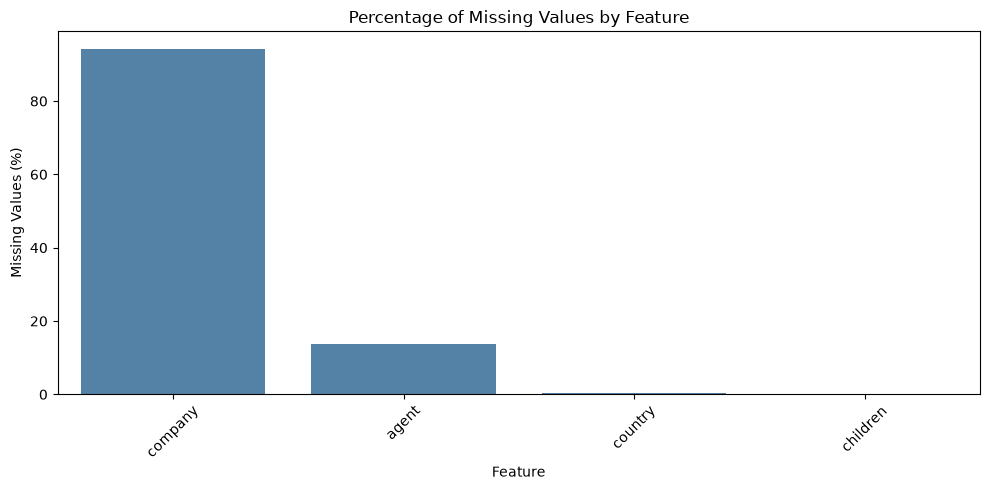

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing Percentage (%)"],
    color="steelblue"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.5.2 Detailed Investigation of Missing Features

The four features containing missing values are investigated individually. Missing values are not assumed to represent the same situation across all features because the meaning of an absent value depends on the context of the attribute.

The investigation therefore considers the amount of missingness, the observed values within each feature, and whether missingness may represent a meaningful booking characteristic rather than a simple data-entry error.

In [33]:
missing_features = ["company", "agent", "country", "children"]

for feature in missing_features:
    print(f"\n{'=' * 50}")
    print(f"Feature: {feature}")
    print(f"{'=' * 50}")
    
    print(f"Missing count: {dq_df[feature].isnull().sum()}")
    print(f"Missing percentage: {dq_df[feature].isnull().mean() * 100:.4f}%")
    print(f"Non-missing count: {dq_df[feature].notnull().sum()}")
    print(f"Unique non-missing values: {dq_df[feature].nunique()}")
    
    print("\nSample / most common non-missing values:")
    print(dq_df[feature].value_counts().head(10))


Feature: company
Missing count: 112593
Missing percentage: 94.3069%
Non-missing count: 6797
Unique non-missing values: 352

Sample / most common non-missing values:
company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
Name: count, dtype: int64

Feature: agent
Missing count: 16340
Missing percentage: 13.6862%
Non-missing count: 103050
Unique non-missing values: 333

Sample / most common non-missing values:
agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

Feature: country
Missing count: 488
Missing percentage: 0.4087%
Non-missing count: 118902
Unique non-missing values: 177

Sample / most common non-missing values:
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: i

### 2.5.3 Missingness and Cancellation Outcome

To determine whether missingness may contain useful information, the cancellation rate is compared between records where each affected feature is missing and records where the feature is present.

A noticeable difference does not establish causation. However, it may indicate that the absence of a value is associated with particular booking characteristics and should therefore be considered carefully during preprocessing.

In [34]:
for feature in missing_features:
    comparison = (
        dq_df.assign(Missing=dq_df[feature].isnull())
        .groupby("Missing")["is_canceled"]
        .agg(["count", "mean"])
        .rename(columns={"count": "Records", "mean": "Cancellation Rate"})
    )
    
    comparison["Cancellation Rate"] = (
        comparison["Cancellation Rate"] * 100
    ).round(2)
    
    print(f"\n{feature.upper()} - Missingness vs Cancellation")
    print(comparison)


COMPANY - Missingness vs Cancellation
         Records  Cancellation Rate
Missing                            
False       6797              17.52
True      112593              38.22

AGENT - Missingness vs Cancellation
         Records  Cancellation Rate
Missing                            
False     103050              39.00
True       16340              24.66

COUNTRY - Missingness vs Cancellation
         Records  Cancellation Rate
Missing                            
False     118902              37.14
True         488              13.73

CHILDREN - Missingness vs Cancellation
         Records  Cancellation Rate
Missing                            
False     119386              37.04
True           4             100.00


### 2.5.4 Missing Value Findings and Recommendations

The missing-value analysis identified four affected features: `company`, `agent`, `country`, and `children`. The severity and possible implications of missingness differ considerably across these attributes.

#### Company

The `company` feature contains 112,593 missing values, representing approximately 94.31% of the dataset. Only 6,797 records contain a company value, with 352 unique non-missing company codes.

A notable difference was also observed in cancellation behaviour. Records with a company value had a cancellation rate of 17.52%, while records with a missing company value had a cancellation rate of 38.22%.

The high level of missingness makes direct numerical imputation inappropriate without further justification. Missing values may also indicate that a booking was not associated with a company rather than representing an unknown value. Therefore, the preprocessing stage should consider either representing the absence of a company explicitly or excluding the feature if its limited availability is considered unsuitable for generalizable modelling.

#### Agent

The `agent` feature contains 16,340 missing values, representing approximately 13.69% of all records.

Bookings with a recorded agent had a cancellation rate of 39.00%, compared with 24.66% among records where the agent value was missing. This difference suggests that missingness in `agent` may contain useful information about the booking process.

A missing agent value may potentially indicate that the booking was not made through an agent. Therefore, automatically applying conventional numerical imputation could remove meaningful information. The preprocessing stage should investigate treating absence of an agent explicitly before deciding on the final representation.

#### Country

The `country` feature contains 488 missing values, representing approximately 0.41% of the dataset. Therefore, missingness in this feature is relatively limited.

Records with a known country had a cancellation rate of 37.14%, whereas

## 2.6 Duplicate Record Analysis

Duplicate records may affect the reliability of analysis and machine learning models by giving repeated observations additional influence. However, identical rows in a hotel booking dataset do not necessarily represent accidental duplication because separate bookings may share the same recorded characteristics.

Therefore, duplicate records are first identified and quantified. Sample duplicate groups are then examined before recommending whether they should be retained or removed.

No duplicate records are removed during this Data Quality Analysis stage.

In [35]:
duplicate_count = dq_df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(dq_df)) * 100

print(f"Total records: {len(dq_df)}")
print(f"Fully duplicated rows: {duplicate_count}")
print(f"Percentage of duplicated rows: {duplicate_percentage}")

Total records: 119390
Fully duplicated rows: 0
Percentage of duplicated rows: 0.0


### 2.6.2 Examination of Duplicate Records

A sample of records belonging to duplicate groups is examined to understand whether the identified duplicates appear to be exact repeated records or potentially separate bookings with identical recorded characteristics.

The presence of identical values across all available features alone is not sufficient evidence to conclude that a record is an accidental duplicate.

In [36]:
duplicate_records = dq_df[dq_df.duplicated(keep=False)].copy()

print(f"Total records belonging to duplicate groups: {len(duplicate_records)}")

duplicate_records.head(10)

Total records belonging to duplicate groups: 0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card


### 2.6.3 Duplicate Group Investigation

The duplicate records are grouped by all dataset features to determine how many distinct combinations occur more than once and how frequently identical records are repeated.

This provides additional evidence about the structure and extent of duplication in the dataset.

In [37]:
duplicate_group_sizes = (
    dq_df
    .groupby(list(dq_df.columns), dropna=False)
    .size()
    .reset_index(name="Frequency")
)

duplicate_groups = duplicate_group_sizes[
    duplicate_group_sizes["Frequency"] > 1
].sort_values("Frequency", ascending=False)

print(f"Number of unique duplicate groups: {len(duplicate_groups)}")
print(f"Largest duplicate group frequency: {duplicate_groups['Frequency'].max()}")

duplicate_groups[["Frequency"]].head(10)

Number of unique duplicate groups: 0
Largest duplicate group frequency: nan


,Frequency


### 2.6.4 Duplicate Analysis Findings and Recommendation

The duplicate analysis found no fully duplicated records within the dataset.

Out of 119,390 total records:

- Fully duplicated rows: **0**
- Percentage of duplicated rows: **0.00%**
- Records belonging to duplicate groups: **0**
- Unique duplicate groups: **0**

The duplicate-group investigation also returned no repeated full-row combinations. Therefore, there is no evidence of exact duplicate records when all 36 available attributes are considered.

As no exact duplicates were identified, duplicate removal is not required based on the current evidence. No records are modified or removed during this stage.

It should be noted that this result refers specifically to full-row duplication. Similar bookings may still exist in the dataset, but bookings sharing some characteristics should not automatically be considered duplicates because separate hotel bookings can legitimately have similar attributes.

## 2.7 Invalid and Unrealistic Value Analysis

Numerical features are examined for values that may be logically invalid, unrealistic, or unusual in the context of hotel bookings.

The purpose of this analysis is to distinguish potential data-quality problems from valid but uncommon observations. Suspicious values are therefore quantified and investigated before any preprocessing decisions are recommended.

Particular attention is given to guest counts, length of stay, lead time, Average Daily Rate (ADR), waiting-list duration, and required car parking spaces.

No suspicious records are removed or modified during this stage.

### 2.7.1 Numerical Range Inspection

The minimum, maximum, median, and selected percentile values of important numerical features are examined to identify potentially invalid or unusually extreme observations.

In [38]:
quality_numeric_features = [
    "adults",
    "children",
    "babies",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr",
    "days_in_waiting_list",
    "required_car_parking_spaces"
]

range_summary = dq_df[quality_numeric_features].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

range_summary[
    ["count", "mean", "std", "min", "1%", "25%", "50%", "75%", "99%", "max"]
].round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max
adults,119390.0,1.86,0.58,0.00,1.0,2.00,2.00,2.0,3.0,55.0
children,119386.0,0.10,0.40,0.00,0.0,0.00,0.00,0.0,2.0,10.0
babies,119390.0,0.01,0.10,0.00,0.0,0.00,0.00,0.0,0.0,10.0
lead_time,119390.0,104.01,106.86,0.00,0.0,18.00,69.00,160.0,444.0,737.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.0,0.00,1.00,2.0,4.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,0.0,1.00,2.00,3.0,10.0,50.0
adr,119390.0,101.83,50.54,-6.38,0.0,69.29,94.58,126.0,252.0,5400.0
days_in_waiting_list,119390.0,2.32,17.59,0.00,0.0,0.00,0.00,0.0,75.0,391.0
required_car_parking_spaces,119390.0,0.06,0.25,0.00,0.0,0.00,0.00,0.0,1.0,8.0


### 2.7.2 Negative Value Check

Features representing counts, durations, and monetary rates are checked for negative values. Negative values in count-based attributes would generally require further investigation because such quantities cannot normally be below zero.

In [39]:
negative_counts = {}

for feature in quality_numeric_features:
    negative_counts[feature] = (dq_df[feature] < 0).sum()

negative_summary = pd.Series(
    negative_counts,
    name="Negative Value Count"
)

negative_summary

adults                         0
children                       0
babies                         0
lead_time                      0
stays_in_weekend_nights        0
stays_in_week_nights           0
adr                            1
days_in_waiting_list           0
required_car_parking_spaces    0
Name: Negative Value Count, dtype: int64

### 2.7.3 Bookings With No Recorded Guests

A valid hotel booking would normally be expected to contain at least one recorded guest. Records are therefore examined where `adults`, `children`, and `babies` are all zero.

Such records may represent data-entry problems, unusual administrative bookings, or another special situation and should be investigated before preprocessing.

In [40]:
zero_guest_mask = (
    (dq_df["adults"] == 0) &
    (dq_df["children"].fillna(0) == 0) &
    (dq_df["babies"] == 0)
)

zero_guest_count = zero_guest_mask.sum()
zero_guest_percentage = (zero_guest_count / len(dq_df)) * 100

print(f"Bookings with zero recorded guests: {zero_guest_count}")
print(f"Percentage of dataset: {zero_guest_percentage:.4f}%")

Bookings with zero recorded guests: 180
Percentage of dataset: 0.1508%


In [41]:
dq_df.loc[
    zero_guest_mask,
    [
        "hotel",
        "is_canceled",
        "adults",
        "children",
        "babies",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adr",
        "reservation_status"
    ]
].head(10)

,hotel,is_canceled,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,adr,reservation_status
2224,Resort Hotel,0,0,0.0,0,0,3,0.0,Check-Out
2409,Resort Hotel,0,0,0.0,0,0,0,0.0,Check-Out
3181,Resort Hotel,0,0,0.0,0,1,2,0.0,Check-Out
3684,Resort Hotel,0,0,0.0,0,1,4,0.0,Check-Out
3708,Resort Hotel,0,0,0.0,0,2,4,0.0,Check-Out
4127,Resort Hotel,1,0,0.0,0,0,0,0.0,Canceled
9376,Resort Hotel,1,0,0.0,0,0,0,0.0,Canceled
31765,Resort Hotel,0,0,0.0,0,2,8,28.0,Check-Out
32029,Resort Hotel,0,0,0.0,0,0,1,0.0,Check-Out
32827,Resort Hotel,0,0,0.0,0,3,9,0.0,Check-Out


### 2.7.4 Zero-Night Stay Investigation

Records where both weekend-night and weekday-night stays are zero are investigated. These observations may represent unusual booking circumstances, cancelled bookings, same-day activity, or potential data-quality issues.

The records are quantified before determining whether any preprocessing action is appropriate.

In [42]:
zero_night_mask = (
    (dq_df["stays_in_weekend_nights"] == 0) &
    (dq_df["stays_in_week_nights"] == 0)
)

zero_night_count = zero_night_mask.sum()
zero_night_percentage = (zero_night_count / len(dq_df)) * 100

print(f"Bookings with zero recorded stay nights: {zero_night_count}")
print(f"Percentage of dataset: {zero_night_percentage:.2f}%")

print("\nCancellation distribution:")
print(
    dq_df.loc[zero_night_mask, "is_canceled"]
    .value_counts()
    .sort_index()
)

Bookings with zero recorded stay nights: 715
Percentage of dataset: 0.60%

Cancellation distribution:
is_canceled
0    680
1     35
Name: count, dtype: int64


### 2.7.5 ADR Value Investigation

The `adr` (Average Daily Rate) feature is examined separately for zero, negative, and unusually large values.

Negative ADR values may require contextual investigation, while very large positive ADR values may represent legitimate premium bookings or potential anomalies. At this stage, these observations are identified rather than automatically treated as errors.

In [43]:
print(f"Minimum ADR: {dq_df['adr'].min()}")
print(f"Maximum ADR: {dq_df['adr'].max()}")
print(f"Negative ADR records: {(dq_df['adr'] < 0).sum()}")
print(f"Zero ADR records: {(dq_df['adr'] == 0).sum()}")

print("\nFive lowest ADR values:")
print(dq_df["adr"].nsmallest(5).to_list())

print("\nFive highest ADR values:")
print(dq_df["adr"].nlargest(5).to_list())

Minimum ADR: -6.38
Maximum ADR: 5400.0
Negative ADR records: 1
Zero ADR records: 1959

Five lowest ADR values:
[-6.38, 0.0, 0.0, 0.0, 0.0]

Five highest ADR values:
[5400.0, 510.0, 508.0, 451.5, 450.0]


### 2.7.6 Invalid and Unrealistic Value Findings

The investigation identified several unusual numerical observations that require consideration during preprocessing.

#### Guest Counts

A total of **180 bookings (0.1508%)** contain zero recorded adults, children, and babies. A hotel booking would normally be expected to include at least one guest, making these records potentially inconsistent.

However, examination of the records showed that some zero-guest bookings contain recorded stay nights and completed reservation statuses. Therefore, these observations cannot automatically be treated as simple data-entry errors. The preprocessing stage should investigate these records further before deciding whether they should be retained or excluded.

The numerical range analysis also identified unusually large guest counts, including a maximum of **55 adults**, **10 children**, and **10 babies**. These values are not automatically classified as invalid but should be investigated further during outlier analysis.

#### Stay Duration

A total of **715 bookings (0.60%)** contain zero recorded weekend nights and zero recorded weekday nights.

Among these records, **680 were not cancelled** and **35 were cancelled**. Since most zero-night records were not cancelled, zero-night stays should not automatically be considered invalid. They may represent unusual booking circumstances or characteristics of how stays were recorded in the dataset.

Unusually long recorded stays were also observed, with maximum values of **19 weekend nights** and **50 weekday nights**. These observations require further assessment during outlier analysis.

#### Average Daily Rate (ADR)

The `adr` feature contains several notable values:

- Minimum ADR: **-6.38**
- Maximum ADR: **5400.00**
- Negative ADR records: **1**
- Zero ADR records: **1,959**

The single negative ADR value is logically unusual because a negative accommodation rate would not normally be expected. This observation should therefore be treated as a potential data-quality issue and investigated further before preprocessing.

Zero ADR values are considerably more common. A zero ADR does not necessarily indicate an error because complimentary stays, special arrangements, or particular booking circumstances may potentially produce a zero recorded rate. Therefore, the 1,959 zero values should not be automatically removed.

The maximum ADR of **5400** is also highly unusual. The next highest observed values were 510, 508, 451.5, and 450, indicating that 5400 is substantially separated from the other extreme ADR observations. This value should be investigated as a potential extreme outlier rather than immediately removed.

#### Lead Time and Waiting List

The maximum observed `lead_time` is **737 days**, compared with a 99th percentile of approximately **444 days**. The maximum `days_in_waiting_list` value is **391 days**, compared with a 99th percentile of approximately **75 days**.

These values are unusual but are not inherently impossible. They should therefore be treated as potential extreme observations and evaluated further during the systematic outlier analysis.

#### Negative Value Assessment

Among the numerical features examined, `adr` was the only feature containing a negative observation. No negative values were identified in guest counts, lead time, stay duration, waiting-list duration, or required car-parking spaces.

#### Overall Finding

The analysis identified a small number of logically questionable observations as well as several extreme but potentially valid values. The zero-guest records and negative ADR observation represent the clearest potential data-quality concerns.

Other observations, including long lead times, long stays, large guest counts, zero ADR values, and large waiting-list durations, require additional investigation before they can be classified as errors or legitimate rare cases.

No records or values are modified during this stage. Potential extreme observations will be examined further during the outlier analysis before final preprocessing recommendations are made.

## 2.8 Outlier Analysis

Potential numerical outliers are systematically investigated using descriptive statistics, boxplots, and the Interquartile Range (IQR) method.

An observation falling outside the IQR boundaries is treated as a potential outlier rather than automatically being classified as an error. In a hotel booking context, extreme values may represent genuine but uncommon booking behaviour.

The purpose of this analysis is therefore to identify and quantify extreme observations, examine their characteristics, and provide appropriate recommendations for the preprocessing stage.

No outliers are removed or modified during this

### 2.8.1 Numerical Features Selected for Outlier Analysis

The following numerical features are examined because unusually high or low values may influence subsequent statistical analysis and machine learning models:

- `lead_time`
- `adr`
- `adults`
- `children`
- `babies`
- `stays_in_weekend_nights`
- `stays_in_week_nights`
- `days_in_waiting_list`
- `previous_cancellations`
- `previous_bookings_not_canceled`
- `booking_changes`

In [44]:
outlier_features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "days_in_waiting_list",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes"
]

dq_df[outlier_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
adr,119390.0,101.83,50.54,-6.38,69.29,94.58,126.0,5400.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
days_in_waiting_list,119390.0,2.32,17.59,0.00,0.00,0.00,0.0,391.0
previous_cancellations,119390.0,0.09,0.84,0.00,0.00,0.00,0.0,26.0
previous_bookings_not_canceled,119390.0,0.14,1.50,0.00,0.00,0.00,0.0,72.0


### 2.8.2 IQR-Based Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers.

For each numerical feature:

- Q1 represents the 25th percentile.
- Q3 represents the 75th percentile.
- IQR is calculated as Q3 - Q1.
- Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are identified as potential outliers.

These boundaries provide a systematic method for detecting unusual observations. However, observations outside the boundaries are not automatically considered erroneous.

In [45]:
outlier_results = []

for feature in outlier_features:
    series = dq_df[feature].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outlier_mask = (series < lower_bound) | (series > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / len(series)) * 100
    
    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary.round(2)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,lead_time,18.00,160.0,142.00,-195.00,373.00,3005,2.52
1,adr,69.29,126.0,56.71,-15.77,211.06,3793,3.18
2,adults,2.00,2.0,0.00,2.00,2.00,29710,24.88
3,children,0.00,0.0,0.00,0.00,0.00,8590,7.20
4,babies,0.00,0.0,0.00,0.00,0.00,917,0.77
5,stays_in_weekend_nights,0.00,2.0,2.00,-3.00,5.00,265,0.22
6,stays_in_week_nights,1.00,3.0,2.00,-2.00,6.00,3354,2.81
7,days_in_waiting_list,0.00,0.0,0.00,0.00,0.00,3698,3.10
8,previous_cancellations,0.00,0.0,0.00,0.00,0.00,6484,5.43
9,previous_bookings_not_canceled,0.00,0.0,0.00,0.00,0.00,3620,3.03


### 2.8.3 Boxplot Visualization of Numerical Features

Boxplots are used to visualize the distributions and potential outliers of the selected numerical attributes.

Points extending beyond the boxplot whiskers indicate potentially unusual observations according to the distribution of each feature. Their presence does not necessarily mean that the observations are invalid.

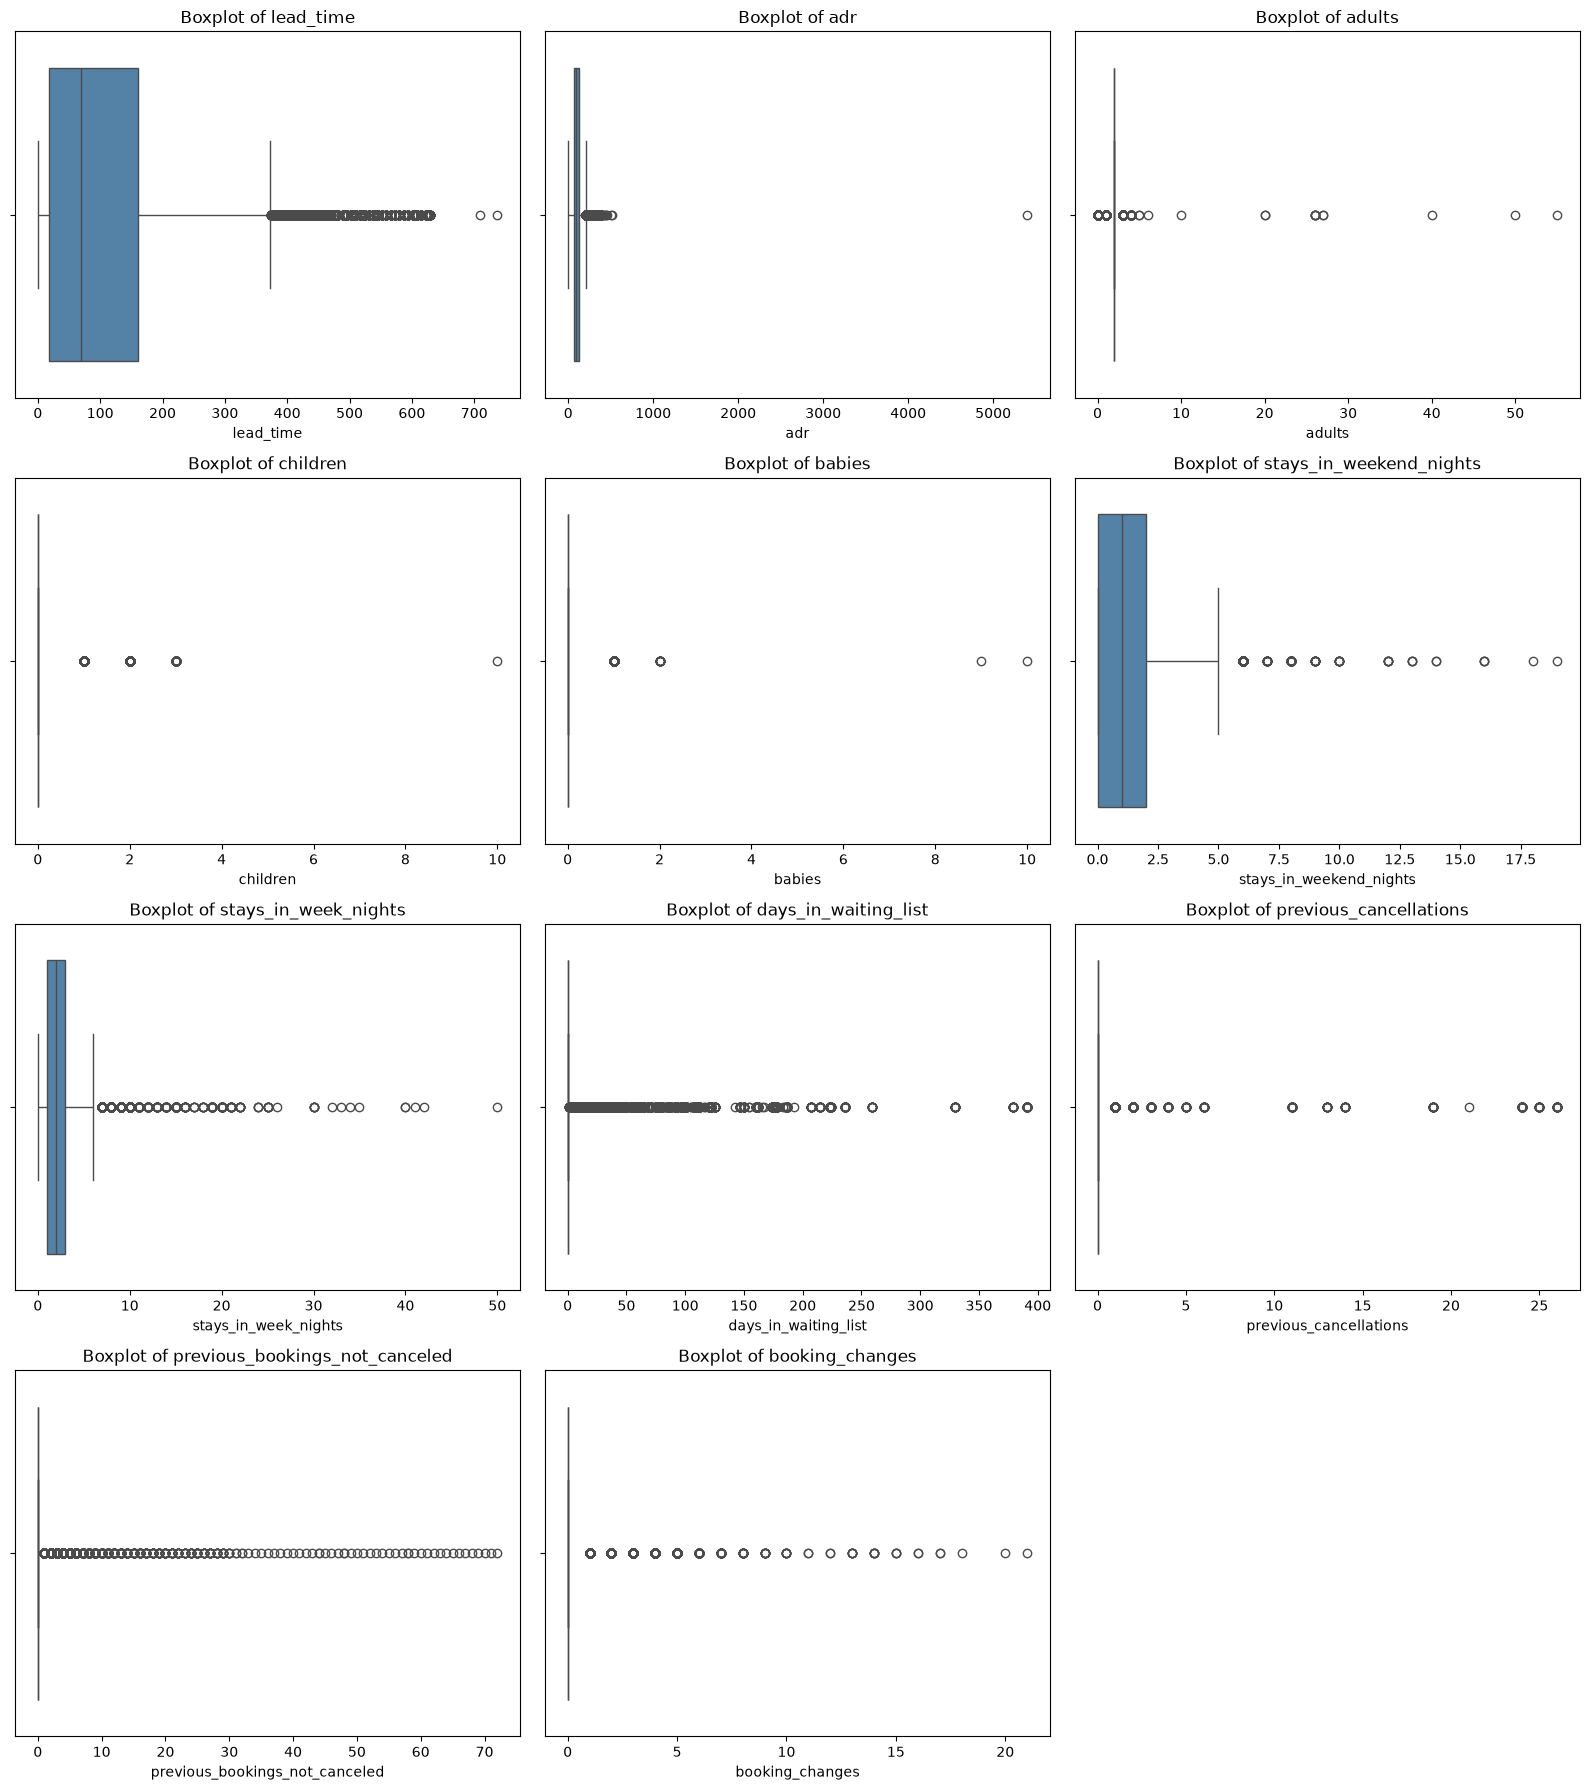

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(outlier_features):
    sns.boxplot(
        x=dq_df[feature],
        ax=axes[i],
        color="steelblue"
    )
    
    axes[i].set_title(f"Boxplot of {feature}")
    axes[i].set_xlabel(feature)

# Remove any unused subplot
for j in range(len(outlier_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.8.4 Examination of Extreme Values

The largest observed values for each numerical feature are examined to determine whether the detected outliers consist of isolated extreme observations or multiple recurring high values.

This helps distinguish potentially erroneous values from genuine but uncommon booking behaviour.

In [47]:
for feature in outlier_features:
    print(f"\n{'=' * 55}")
    print(f"Feature: {feature}")
    print(f"{'=' * 55}")
    
    print("Five largest values:")
    print(dq_df[feature].nlargest(5).to_list())


Feature: lead_time
Five largest values:
[737, 709, 629, 629, 629]

Feature: adr
Five largest values:
[5400.0, 510.0, 508.0, 451.5, 450.0]

Feature: adults
Five largest values:
[55, 50, 40, 27, 27]

Feature: children
Five largest values:
[10.0, 3.0, 3.0, 3.0, 3.0]

Feature: babies
Five largest values:
[10, 9, 2, 2, 2]

Feature: stays_in_weekend_nights
Five largest values:
[19, 18, 16, 16, 16]

Feature: stays_in_week_nights
Five largest values:
[50, 42, 41, 40, 40]

Feature: days_in_waiting_list
Five largest values:
[391, 391, 391, 391, 391]

Feature: previous_cancellations
Five largest values:
[26, 26, 26, 26, 26]

Feature: previous_bookings_not_canceled
Five largest values:
[72, 71, 70, 69, 68]

Feature: booking_changes
Five largest values:
[21, 20, 18, 17, 17]


### 2.8.5 Investigation of the Extreme ADR Observation

The maximum ADR value is substantially larger than the other high ADR observations. The corresponding booking record is therefore examined separately to provide additional context before making a preprocessing recommendation.

In [48]:
dq_df.loc[
    dq_df["adr"] == dq_df["adr"].max(),
    [
        "hotel",
        "is_canceled",
        "lead_time",
        "adults",
        "children",
        "babies",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "market_segment",
        "deposit_type",
        "customer_type",
        "adr"
    ]
]

,hotel,is_canceled,lead_time,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,market_segment,deposit_type,customer_type,adr
48515,City Hotel,1,35,2,0.0,0,0,1,Offline TA/TO,Non Refund,Transient,5400.0


### 2.8.6 Outlier Analysis Findings and Recommendations

The IQR analysis and boxplot visualizations identified potential outliers across several numerical features. However, the results show that statistical outliers should not automatically be interpreted as data errors.

#### Lead Time

The IQR method identified **3,005 potential outliers (2.52%)** in `lead_time`, with an upper IQR boundary of **373 days**.

The largest observed lead times were **737, 709, 629, 629, and 629 days**. These values are unusually high but are not logically impossible because reservations may be made far in advance.

Therefore, long lead times should be treated as valid but extreme observations unless additional evidence indicates that they are erroneous.

#### Average Daily Rate (ADR)

The IQR method identified **3,793 potential ADR outliers (3.18%)**, with an upper boundary of approximately **211.06**.

The five highest ADR values were:

- 5400.0
- 510.0
- 508.0
- 451.5
- 450.0

The maximum ADR of **5400** is substantially separated from the rest of the observed high ADR values. Examination of the corresponding record showed a City Hotel booking involving two adults, one weekday night, a lead time of 35 days, an Offline TA/TO market segment, a Non Refund deposit, and a Transient customer type.

Although the surrounding booking attributes appear structurally plausible, the ADR value of 5400 is exceptionally large compared with the next highest ADR of 510. It should therefore be treated as a potentially anomalous extreme value and specifically reviewed during preprocessing.

The previously identified negative ADR value of **-6.38** should also receive special consideration because a negative accommodation rate is logically unusual.

#### Guest Counts

The IQR method classified a relatively large proportion of `adults` values as outliers. However, `adults` has Q1 = 2 and Q3 = 2, producing an IQR of zero. Consequently, any value other than 2 can be classified as an outlier by this method.

A similar limitation occurs for `children` and `babies`, whose distributions are strongly concentrated at zero.

The maximum values of **55 adults**, **10 children**, and **10 babies** are unusual and should be investigated as extreme cases. However, ordinary non-zero guest counts should not be removed simply because the IQR method identifies them as outliers.

#### Length of Stay

The IQR method identified **265 potential outliers (0.22%)** in weekend-night stays and **3,354 potential outliers (2.81%)** in weekday-night stays.

Maximum observed values were **19 weekend nights** and **50 weekday nights**. Although these stays are considerably longer than typical bookings, long hotel stays are possible. Therefore, these observations should initially be regarded as rare cases rather than definite errors.

#### Waiting List

The `days_in_waiting_list` feature is strongly concentrated at zero. Because Q1 and Q3 are both zero, the IQR becomes zero and all positive waiting-list values are flagged by the standard IQR rule.

The analysis identified **3,698 records (3.10%)** as potential IQR outliers, with a maximum waiting-list duration of **391 days**.

Positive waiting-list values should not automatically be treated as invalid because they represent meaningful booking behaviour. Extremely long waiting-list durations may require separate investigation.

#### Previous Booking Behaviour and Booking Changes

The features `previous_cancellations`, `previous_bookings_not_canceled`, and `booking_changes` also have Q1 and Q3 values of zero.

As a result, any positive value is classified as an IQR outlier. This produced:

- **6,484 (5.43%)** potential outliers for `previous_cancellations`
- **3,620 (3.03%)** potential outliers for `previous_bookings_not_canceled`
- **18,076 (15.14%)** potential outliers for `booking_changes`

These observations should not be automatically removed because non-zero values represent legitimate historical booking behaviour and booking modifications.

#### Overall Outlier Assessment

The analysis demonstrates an important limitation of applying the IQR method mechanically to highly skewed or zero-concentrated variables. For several features, Q1 and Q3 are identical, producing an IQR of zero and causing every non-zero observation to be labelled as a statistical outlier.

Therefore, IQR results should be interpreted together with feature meaning, descriptive statistics, distributions, boxplots, and the magnitude of individual extreme observations.

Particular attention should be given during preprocessing to the extreme ADR value of 5400, the negative ADR value of -6.38, unusually large guest counts, and other highly extreme observations. However, no outliers are removed or transformed during the Data Quality Analysis stage.

## 2.9 Class Distribution Assessment

The target variable `is_canceled` is examined to assess the balance between cancelled and non-cancelled hotel bookings.

Class imbalance can influence machine learning models because a model may become biased toward the majority class when one outcome is substantially more frequent than another.

At this stage, the objective is only to quantify and assess the target distribution. No resampling technique such as SMOTE, undersampling, or oversampling is applied.

In [49]:
class_counts = dq_df["is_canceled"].value_counts().sort_index()
class_percentages = (
    dq_df["is_canceled"].value_counts(normalize=True).sort_index() * 100
)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

class_summary.index = ["Not Cancelled (0)", "Cancelled (1)"]

class_summary.round(2)

,Count,Percentage (%)
Not Cancelled (0),75166,62.96
Cancelled (1),44224,37.04


### 2.9.2 Class Distribution Visualization

The target distribution is visualized to provide a clear comparison between cancelled and non-cancelled bookings.

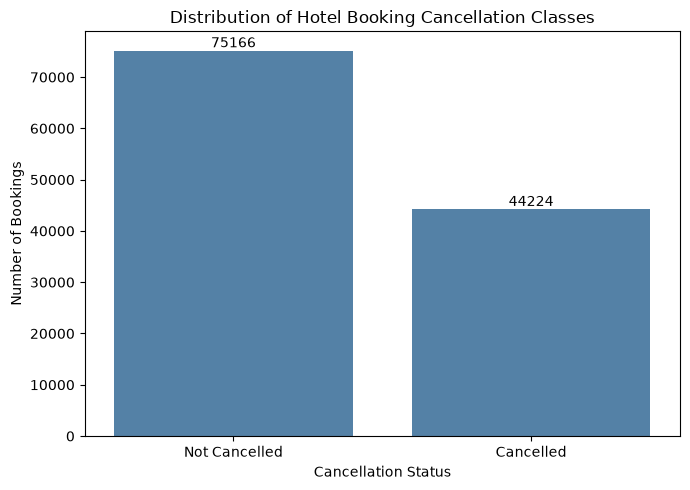

In [50]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x="is_canceled",
    data=dq_df,
    color="steelblue"
)

plt.title("Distribution of Hotel Booking Cancellation Classes")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 2.9.3 Class Imbalance Ratio

The ratio between the majority and minority classes is calculated to help assess the severity of the class imbalance.

In [51]:
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print(f"Majority class records: {majority_count}")
print(f"Minority class records: {minority_count}")
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

Majority class records: 75166
Minority class records: 44224
Majority-to-minority ratio: 1.70:1


### 2.9.4 Class Distribution Findings and Recommendation

The target variable `is_canceled` contains:

- **75,166 Not Cancelled bookings (62.96%)**
- **44,224 Cancelled bookings (37.04%)**

The majority-to-minority class ratio is approximately **1.70:1**.

The dataset therefore shows a moderate class imbalance, with non-cancelled bookings representing the majority class. However, the minority class remains well represented with more than 44,000 cancelled bookings and accounts for 37.04% of the complete dataset.

Based on the current evidence, the imbalance is not considered severe enough to justify automatically applying a resampling technique such as SMOTE at the Data Quality Analysis stage.

During model development, the group should evaluate model performance using metrics that consider performance across both classes rather than relying only on overall accuracy. The need for resampling or class-weighting should then be determined based on validation results and the behaviour of the selected machine learning algorithms.

No class-balancing technique is applied during this stage.

## 2.10 Rare Category Analysis

Categorical features are examined to identify categories that occur very infrequently within the dataset.

Rare categories may create challenges during preprocessing and modelling because they are represented by only a small number of observations. When categorical encoding is applied later, very small categories may produce sparse features or patterns that do not generalize well to unseen data.

The purpose of this analysis is to identify and quantify rare categories rather than automatically removing or combining them.

No categorical values are modified during this stage.

### 2.10.1 Category Frequency Analysis

The frequency and percentage of each category are calculated for the categorical features identified for detailed investigation.

Both the number of observations and their proportion of the complete dataset are considered when assessing whether a category is rare.

In [52]:
categorical_features = [
    "market_segment",
    "deposit_type",
    "customer_type",
    "meal",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "country"
]

for feature in categorical_features:
    counts = dq_df[feature].value_counts(dropna=False)
    percentages = (
        dq_df[feature].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )

    category_summary = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages
    })

    print(f"\n{'=' * 60}")
    print(f"Feature: {feature}")
    print(f"Unique categories: {dq_df[feature].nunique(dropna=False)}")
    print(f"{'=' * 60}")

    display(category_summary.round(3))


Feature: market_segment
Unique categories: 8


,Count,Percentage (%)
market_segment,,
Online TA,56477,47.305
Offline TA/TO,24219,20.286
Groups,19811,16.594
Direct,12606,10.559
Corporate,5295,4.435
Complementary,743,0.622
Aviation,237,0.199
Undefined,2,0.002



Feature: deposit_type
Unique categories: 3


,Count,Percentage (%)
deposit_type,,
No Deposit,104641,87.646
Non Refund,14587,12.218
Refundable,162,0.136



Feature: customer_type
Unique categories: 4


...

,Count,Percentage (%)
reserved_room_type,,
A,85994,72.028
D,19201,16.083
E,6535,5.474
F,2897,2.427
G,2094,1.754
B,1118,0.936
C,932,0.781
H,601,0.503
P,12,0.010



Feature: assigned_room_type
Unique categories: 12


,Count,Percentage (%)
assigned_room_type,,
A,74053,62.026
D,25322,21.209
E,7806,6.538
F,3751,3.142
G,2553,2.138
C,2375,1.989
B,2163,1.812
H,712,0.596
I,363,0.304



Feature: country
Unique categories: 178


,Count,Percentage (%)
country,,
PRT,48590,40.699
GBR,12129,10.159
FRA,10415,8.724
ESP,8568,7.176
DEU,7287,6.104
...,...,...
NCL,1,0.001
KIR,1,0.001
SDN,1,0.001


### 2.10.2 Identification of Rare Categories

For exploratory purposes, categories representing less than **0.1%** of the complete dataset are flagged as rare.

This threshold is used only to systematically identify categories requiring further attention. A category being labelled as rare does not mean that it should automatically be removed or combined during preprocessing.

In [53]:
rare_threshold = 0.1

rare_category_results = []

for feature in categorical_features:
    counts = dq_df[feature].value_counts(dropna=False)
    percentages = (
        dq_df[feature].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )

    for category in counts.index:
        percentage = percentages.loc[category]

        if percentage < rare_threshold:
            rare_category_results.append({
                "Feature": feature,
                "Category": category,
                "Count": counts.loc[category],
                "Percentage (%)": percentage
            })

rare_categories = pd.DataFrame(rare_category_results)

rare_categories = rare_categories.sort_values(
    ["Feature", "Percentage (%)"],
    ascending=[True, True]
)

rare_categories.round(4)

,Feature,Category,Count,Percentage (%)
5,assigned_room_type,L,1,0.0008
4,assigned_room_type,P,12,0.0101
118,country,BWA,1,0.0008
119,country,SMR,1,0.0008
120,country,CYM,1,0.0008
...,...,...,...,...
6,country,DZA,103,0.0863
1,distribution_channel,Undefined,5,0.0042
0,market_segment,Undefined,2,0.0017
3,reserved_room_type,L,6,0.0050


### 2.10.3 Rare Category Summary by Feature

The number of categories falling below the exploratory 0.1% threshold is summarized for each feature. This helps identify which categorical attributes contain the greatest degree of category sparsity.

In [54]:
rare_count_summary = (
    rare_categories
    .groupby("Feature")
    .size()
    .reindex(categorical_features, fill_value=0)
    .reset_index(name="Number of Rare Categories")
)

rare_count_summary

,Feature,Number of Rare Categories
0,market_segment,1
1,deposit_type,0
2,customer_type,0
3,meal,0
4,distribution_channel,1
5,reserved_room_type,2
6,assigned_room_type,2
7,country,142


### 2.10.4 Investigation of Previously Identified Rare Categories

The initial EDA highlighted particularly uncommon categories within `market_segment` and `deposit_type`. These categories are independently verified during the Data Quality Analysis.

In [55]:
checks = [
    ("market_segment", "Undefined"),
    ("deposit_type", "Refundable")
]

for feature, category in checks:
    count = (dq_df[feature] == category).sum()
    percentage = (count / len(dq_df)) * 100

    print(f"{feature} = {category}")
    print(f"Count: {count}")
    print(f"Percentage: {percentage:.4f}%")
    print("-" * 40)

market_segment = Undefined
Count: 2
Percentage: 0.0017%
----------------------------------------
deposit_type = Refundable
Count: 162
Percentage: 0.1357%
----------------------------------------


### 2.10.5 Rare Category Findings and Recommendations

The categorical frequency analysis identified several categories that occur very infrequently in the dataset. For exploratory purposes, categories representing less than 0.1% of the complete dataset were flagged as rare.

Using this threshold, rare categories were identified in `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, and particularly `country`.

#### Market Segment

The `market_segment` feature contains eight categories. The `Undefined` category contains only **2 records (0.0017%)**, making it extremely rare.

Because this category is represented by only two observations, patterns associated with it are unlikely to be reliable. However, the category is not removed or merged during this stage. Its treatment should be considered during categorical preprocessing.

#### Deposit Type

The `deposit_type` feature contains three categories:

- `No Deposit`: 104,641 records (87.646%)
- `Non Refund`: 14,587 records (12.218%)
- `Refundable`: 162 records (0.136%)

The `Refundable` category does not fall below the exploratory 0.1% threshold, but it remains uncommon relative to the other deposit types. Therefore, its behaviour should be interpreted carefully.

The `Non Refund` category is not rare, representing more than 12% of the dataset. However, its previously observed unusually high cancellation rate requires a separate investigation.

#### Customer Type and Meal

No categories within `customer_type` or `meal` fell below the 0.1% exploratory threshold.

Although some categories are substantially less frequent than the dominant categories, the current analysis does not provide sufficient evidence to classify them as severe data-quality concerns.

#### Distribution Channel

The `Undefined` distribution channel contains only **5 records (approximately 0.004%)** and was identified as a rare category.

Because the category contains very few records, its representation during categorical encoding should be considered carefully during preprocessing.

#### Room Types

The `reserved_room_type` feature contains two categories below the 0.1% threshold:

- `L`: 6 records
- `P`: 12 records

The `assigned_room_type` feature also contains two categories below the threshold:

- `L`: 1 record
- `P`: 12 records

These categories are extremely sparsely represented. They should be reviewed during preprocessing rather than automatically removed or combined.

#### Country

The `country` feature contains **178 categories**, indicating relatively high categorical cardinality.

Using the exploratory 0.1% threshold, **142 country categories** were identified as rare. Several country codes are represented by only a single booking.

This level of sparsity may create a large number of low-frequency features if conventional one-hot encoding is applied directly. Therefore, the treatment of rare country categories should receive particular attention during preprocessing.

Possible approaches may include grouping sufficiently rare categories into a broader category or selecting an encoding strategy appropriate for high-cardinality categorical data. Any grouping decision should be performed only after defining and justifying an appropriate preprocessing rule.

#### Overall Finding

Rare-category severity varies substantially across the categorical features. The greatest concern is `country`, where a large number of categories have very limited representation. Extremely rare values were also identified in `market_segment`, `distribution_channel`, `reserved_room_type`, and `assigned_room_type`.

The 0.1% threshold used in this analysis is an exploratory screening criterion rather than an automatic preprocessing rule. Categories should not be removed or merged solely because they fall below this threshold.

No categorical values are modified during the Data Quality Analysis stage. Final treatment decisions should be made during preprocessing based on category meaning, frequency, encoding strategy, and potential impact on model generalization.

## 2.11 Investigation of the Non Refund Deposit Pattern

The initial EDA identified an unusual relationship between `deposit_type` and booking cancellation. Bookings with a `Non Refund` deposit appeared to have an exceptionally high cancellation rate.

This section investigates the pattern in greater detail to determine whether it is associated with particular booking characteristics or represents a potential data-quality concern.

The investigation considers:

- Hotel type
- Market segment
- Lead time
- Customer type
- Repeated guest status
- Previous cancellations

The purpose of this analysis is to identify associations and unusual patterns rather than establish a causal relationship between deposit type and cancellation.

### 2.11.1 Confirmation of the Non Refund Cancellation Pattern

The number of `Non Refund` bookings and their observed cancellation rate are independently calculated before investigating relationships with other booking characteristics.

In [56]:
non_refund = dq_df[dq_df["deposit_type"] == "Non Refund"].copy()

non_refund_count = len(non_refund)
non_refund_cancelled = non_refund["is_canceled"].sum()
non_refund_cancel_rate = non_refund["is_canceled"].mean() * 100

print(f"Total Non Refund bookings: {non_refund_count}")
print(f"Cancelled Non Refund bookings: {non_refund_cancelled}")
print(f"Not Cancelled Non Refund bookings: {non_refund_count - non_refund_cancelled}")
print(f"Non Refund cancellation rate: {non_refund_cancel_rate:.2f}%")

Total Non Refund bookings: 14587
Cancelled Non Refund bookings: 14494
Not Cancelled Non Refund bookings: 93
Non Refund cancellation rate: 99.36%


### 2.11.2 Non Refund Pattern by Hotel Type

The `Non Refund` bookings are examined across hotel types to determine whether the unusually high cancellation rate is concentrated within a particular hotel category.

In [57]:
hotel_non_refund = (
    non_refund
    .groupby("hotel")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

hotel_non_refund.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

hotel_non_refund["Cancellation Rate"] = (
    hotel_non_refund["Cancellation Rate"] * 100
).round(2)

hotel_non_refund

,Bookings,Cancelled,Cancellation Rate
hotel,,,
City Hotel,12868,12844,99.81
Resort Hotel,1719,1650,95.99


### 2.11.3 Non Refund Pattern by Market Segment

Market segments within the `Non Refund` subset are examined to determine whether the high cancellation rate is associated primarily with particular booking channels or customer sources.

In [58]:
market_non_refund = (
    non_refund
    .groupby("market_segment")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

market_non_refund.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

market_non_refund["Cancellation Rate"] = (
    market_non_refund["Cancellation Rate"] * 100
).round(2)

market_non_refund.sort_values("Bookings", ascending=False)

,Bookings,Cancelled,Cancellation Rate
market_segment,,,
Groups,9172,9110,99.32
Offline TA/TO,5006,5003,99.94
Corporate,334,312,93.41
Online TA,56,53,94.64
Direct,19,16,84.21


### 2.11.4 Non Refund Pattern by Customer Type

Customer types are compared within the `Non Refund` subset to determine whether the observed cancellation pattern is concentrated among specific types of customers.

In [59]:
customer_non_refund = (
    non_refund
    .groupby("customer_type")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

customer_non_refund.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

customer_non_refund["Cancellation Rate"] = (
    customer_non_refund["Cancellation Rate"] * 100
).round(2)

customer_non_refund.sort_values("Bookings", ascending=False)

,Bookings,Cancelled,Cancellation Rate
customer_type,,,
Transient,12909,12909,100.0
Transient-Party,1134,1041,91.8
Contract,544,544,100.0


### 2.11.5 Non Refund Pattern by Repeated Guest Status

Repeated and non-repeated guests are compared within the `Non Refund` subset to examine whether previous guest relationships are associated with the unusual cancellation pattern.

In [60]:
repeated_non_refund = (
    non_refund
    .groupby("is_repeated_guest")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

repeated_non_refund.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

repeated_non_refund["Cancellation Rate"] = (
    repeated_non_refund["Cancellation Rate"] * 100
).round(2)

repeated_non_refund.index = [
    "Not Repeated Guest (0)" if x == 0 else "Repeated Guest (1)"
    for x in repeated_non_refund.index
]

repeated_non_refund

,Bookings,Cancelled,Cancellation Rate
Not Repeated Guest (0),14523,14434,99.39
Repeated Guest (1),64,60,93.75


### 2.11.6 Lead Time Characteristics

Lead-time characteristics of `Non Refund` bookings are examined separately for cancelled and non-cancelled records.

This helps determine whether the unusual cancellation pattern is associated with substantially different booking lead times.

In [61]:
lead_time_non_refund = (
    non_refund
    .groupby("is_canceled")["lead_time"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

lead_time_non_refund.index = [
    "Not Cancelled (0)",
    "Cancelled (1)"
]

lead_time_non_refund

,count,mean,median,min,max
Not Cancelled (0),93,106.22,171.0,0,226
Cancelled (1),14494,213.59,186.0,0,629


### 2.11.7 Previous Cancellation Behaviour

Previous cancellation history is examined within the `Non Refund` subset to determine whether customers with previous cancellations show a different pattern from customers without previous cancellations.

In [62]:
non_refund = non_refund.copy()

non_refund["has_previous_cancellation"] = (
    non_refund["previous_cancellations"] > 0
).astype(int)

previous_cancel_non_refund = (
    non_refund
    .groupby("has_previous_cancellation")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

previous_cancel_non_refund.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

previous_cancel_non_refund["Cancellation Rate"] = (
    previous_cancel_non_refund["Cancellation Rate"] * 100
).round(2)

previous_cancel_non_refund.index = [
    "No Previous Cancellation",
    "Has Previous Cancellation"
]

previous_cancel_non_refund

,Bookings,Cancelled,Cancellation Rate
No Previous Cancellation,10941,10848,99.15
Has Previous Cancellation,3646,3646,100.00


### 2.11.8 Non Refund Deposit Pattern Findings

The detailed investigation confirms an exceptionally strong association between the `Non Refund` deposit type and booking cancellation.

A total of **14,587 bookings** had a `Non Refund` deposit. Of these, **14,494 were cancelled** and only **93 were not cancelled**, resulting in an overall cancellation rate of **99.36%**.

#### Hotel Type

The high cancellation pattern was observed across both hotel types:

- City Hotel: 12,868 bookings with a **99.81% cancellation rate**
- Resort Hotel: 1,719 bookings with a **95.99% cancellation rate**

The pattern is therefore not limited to a single hotel type, although most Non Refund bookings occurred in City Hotels.

#### Market Segment

Most Non Refund bookings were concentrated in the `Groups` and `Offline TA/TO` market segments.

- Groups: 9,172 bookings with a **99.32% cancellation rate**
- Offline TA/TO: 5,006 bookings with a **99.94% cancellation rate**
- Corporate: 334 bookings with a **93.41% cancellation rate**
- Online TA: 56 bookings with a **94.64% cancellation rate**
- Direct: 19 bookings with an **84.21% cancellation rate**

The extremely high cancellation pattern therefore appears across several market segments rather than being restricted to only one segment. However, the majority of Non Refund observations are concentrated within Groups and Offline TA/TO.

#### Customer Type

The pattern also varies somewhat by customer type:

- Transient: 12,909 bookings with a **100% cancellation rate**
- Transient-Party: 1,134 bookings with a **91.80% cancellation rate**
- Contract: 544 bookings with a **100% cancellation rate**

The Transient category dominates the Non Refund subset, and all 12,909 of these bookings were cancelled. Contract bookings also showed a 100% cancellation rate.

This strengthens the evidence that the unusual cancellation pattern is strongly associated with particular combinations of booking characteristics.

#### Repeated Guest Status

Among Non Refund bookings:

- Not Repeated Guests: 14,523 bookings with a **99.39% cancellation rate**
- Repeated Guests: 64 bookings with a **93.75% cancellation rate**

The vast majority of Non Refund bookings were made by guests not identified as repeated guests. Although repeated guests showed a slightly lower cancellation rate, the number of repeated-guest observations is very small and should be interpreted cautiously.

#### Lead Time

Cancelled Non Refund bookings had a mean lead time of approximately **213.59 days** and a median of **186 days**.

In comparison, the 93 Non Refund bookings that were not cancelled had a mean lead time of approximately **106.22 days** and a median of **171 days**.

This suggests that cancelled Non Refund bookings tend to have a higher average lead time. However, the comparison should be interpreted cautiously because the non-cancelled group contains only 93 observations compared with 14,494 cancelled observations.

#### Previous Cancellation History

Previous cancellation behaviour also showed a strong pattern:

- No Previous Cancellation: 10,941 bookings with a **99.15% cancellation rate**
- Has Previous Cancellation: 3,646 bookings with a **100% cancellation rate**

All Non Refund bookings associated with customers who had at least one previous cancellation were cancelled in the current dataset.

However, even bookings without a previous cancellation history showed an extremely high cancellation rate. Therefore, previous cancellation history alone does not explain the overall Non Refund pattern.

#### Overall Assessment

The investigation shows that the approximately **99.36% cancellation rate associated with Non Refund bookings is not confined to a single hotel type, market segment, customer type, repeated-guest group, or previous-cancellation group**.

The pattern is particularly concentrated among City Hotel bookings, Groups and Offline TA/TO market segments, Transient customers, and non-repeated guests. However, high cancellation rates remain visible across most of the examined subgroups.

This extremely strong association should be documented and investigated carefully during modelling because `deposit_type` may become a highly influential predictive feature.

However, the analysis establishes an **association rather than causation**. The results do not demonstrate that selecting a Non Refund deposit causes a booking to be cancelled.

The unusual strength of the relationship should also be considered from a data-quality perspective. Before modelling, the group should verify that `deposit_type` represents information available at the intended prediction time and does not indirectly encode information created after the cancellation outcome.

No values are modified or removed during this investigation.

## 2.12 Data Leakage Confirmation

Data leakage occurs when information that would not legitimately be available at the intended prediction time is included as an input to a machine learning model.

Leakage can produce unrealistically high model performance because the model may indirectly or directly receive information about the outcome it is supposed to predict.

The initial EDA identified `reservation_status` and `reservation_status_date` as potential post-outcome features. This section independently confirms their relationship with the target variable `is_canceled`.

The features are investigated for data-quality and modelling suitability only. They are not removed from the raw dataset during this stage.

### 2.12.1 Reservation Status and Cancellation Target

The relationship between `reservation_status` and `is_canceled` is examined using a cross-tabulation.

If reservation status consistently identifies whether a booking was cancelled or completed, then the feature contains direct information about the final booking outcome and would cause target leakage if used for prediction.

In [63]:
status_target_table = pd.crosstab(
    dq_df["reservation_status"],
    dq_df["is_canceled"],
    margins=True
)

status_target_table.columns = [
    "Not Cancelled (0)",
    "Cancelled (1)",
    "Total"
]

status_target_table

,Not Cancelled (0),Cancelled (1),Total
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


### 2.12.2 Cancellation Rate by Reservation Status

The cancellation rate for each reservation status is calculated to quantify how strongly the feature reveals the final booking outcome.

In [64]:
status_cancellation = (
    dq_df
    .groupby("reservation_status")["is_canceled"]
    .agg(["count", "sum", "mean"])
)

status_cancellation.columns = [
    "Bookings",
    "Cancelled",
    "Cancellation Rate"
]

status_cancellation["Cancellation Rate"] = (
    status_cancellation["Cancellation Rate"] * 100
).round(2)

status_cancellation

,Bookings,Cancelled,Cancellation Rate
reservation_status,,,
Canceled,43017,43017,100.0
Check-Out,75166,0,0.0
No-Show,1207,1207,100.0


### 2.12.3 Reservation Status Date Leakage Risk

The `reservation_status_date` feature records the date associated with the final reservation status.

Although this feature may not directly encode cancellation as clearly as `reservation_status`, it is associated with the reservation outcome and may contain information that becomes available only after the booking status has been determined.

Therefore, its availability at the intended prediction time must be considered before including it in a predictive model.

In [65]:
print("Reservation status date information:")
print(f"Missing values: {dq_df['reservation_status_date'].isnull().sum()}")
print(f"Unique dates: {dq_df['reservation_status_date'].nunique()}")
print(f"Earliest value: {dq_df['reservation_status_date'].min()}")
print(f"Latest value: {dq_df['reservation_status_date'].max()}")

Reservation status date information:
Missing values: 0
Unique dates: 926
Earliest value: 2014-10-17
Latest value: 2017-09-14


### 2.12.4 Artificial Identification Features

The initial EDA identified the following attributes as artificial identification-related features:

- `name`
- `email`
- `phone-number`
- `credit_card`

These attributes primarily identify individual booking records rather than describing generalizable hotel booking behaviour.

Including such attributes in a predictive feature set could introduce unnecessary high-cardinality information and encourage the model to learn record-specific patterns rather than meaningful booking behaviour.

These attributes are therefore documented for exclusion from the predictive feature set during preprocessing. They remain unchanged in the raw dataset.

In [66]:
identifier_features = [
    "name",
    "email",
    "phone-number",
    "credit_card"
]

identifier_summary = pd.DataFrame({
    "Feature": identifier_features,
    "Non-Missing Values": [
        dq_df[col].notnull().sum()
        for col in identifier_features
    ],
    "Unique Values": [
        dq_df[col].nunique()
        for col in identifier_features
    ]
})

identifier_summary

,Feature,Non-Missing Values,Unique Values
0,name,119390,81503
1,email,119390,115889
2,phone-number,119390,119390
3,credit_card,119390,9000


### 2.12.5 Data Leakage Findings and Recommendations

The data leakage investigation confirms that `reservation_status` contains direct information about the target variable `is_canceled`.

#### Reservation Status

The cross-tabulation between `reservation_status` and `is_canceled` produced the following results:

- All **43,017 `Canceled`** reservation-status records correspond to cancelled bookings.
- All **75,166 `Check-Out`** records correspond to non-cancelled bookings.
- All **1,207 `No-Show`** records correspond to cancelled bookings.

The cancellation rates were therefore:

- `Canceled`: **100%**
- `Check-Out`: **0%**
- `No-Show`: **100%**

This demonstrates that `reservation_status` directly reveals the final booking outcome. Including this feature in a model designed to predict cancellation would cause severe target leakage and could produce unrealistically high model performance.

Therefore, `reservation_status` should be excluded from the predictive feature set before model training.

#### Reservation Status Date

The `reservation_status_date` feature contains no missing values and includes **926 unique dates**, ranging from **2014-10-17** to **2017-09-14**.

This attribute represents the date associated with the final reservation status. Because the information may become available only after the reservation outcome has been determined, including it in a cancellation prediction model could introduce post-outcome information.

Therefore, `reservation_status_date` should also be excluded from the predictive feature set unless the group can clearly demonstrate that the required date information would be available at the intended prediction time without revealing the booking outcome.

#### Artificial Identification Features

The following identification-related attributes were also examined:

- `name`: 81,503 unique values
- `email`: 115,889 unique values
- `phone-number`: 119,390 unique values
- `credit_card`: 9,000 unique values

All four features contain values for all 119,390 records. Their high cardinality, particularly the fact that every `phone-number` value is unique, indicates that these attributes primarily identify individual records rather than describe generalizable booking behaviour.

These features should therefore be excluded from the predictive feature set during preprocessing.

Removing them from the model inputs can reduce unnecessary high-cardinality information and prevent the model from learning record-specific patterns that are unlikely to generalize to future bookings.

#### Overall Leakage Assessment

`reservation_status` represents a clear and severe target-leakage risk because it directly reveals whether the booking was cancelled or completed.

`reservation_status_date` is also considered unsuitable for the intended predictive modelling scenario because it is associated with the final reservation outcome and may contain information unavailable at prediction time.

The artificial identification features `name`, `email`, `phone-number`, and `credit_card` do not represent meaningful generalizable booking behaviour and should not be used as predictive inputs.

These features remain unchanged in the raw dataset during Data Quality Analysis. Their exclusion should be implemented by Member 03 when constructing the preprocessing and modelling feature set.

## 2.13 Data Quality Summary

The Data Quality Analysis identified several issues and unusual patterns that may influence the preprocessing and modelling stages of the project.

The following summary consolidates the main findings from the investigation, including the supporting evidence, estimated severity, and recommended treatment.

The recommendations represent proposed preprocessing actions only. No permanent cleaning or transformation has been applied to the raw dataset during this analysis.

### 2.13.1 Summary of Identified Data Quality Issues

The table below summarizes the main data quality findings identified during the analysis. Severity is assigned according to the potential impact of each issue on preprocessing, modelling reliability, or model generalization.

In [67]:
data_quality_summary = pd.DataFrame([
    {
        "Issue": "Missing Values",
        "Feature(s)": "company",
        "Evidence": "112,593 missing (94.31%)",
        "Severity": "High",
        "Recommended Treatment": "Consider explicit absence representation or exclusion due to extremely high missingness."
    },
    {
        "Issue": "Missing Values",
        "Feature(s)": "agent",
        "Evidence": "16,340 missing (13.69%)",
        "Severity": "Medium",
        "Recommended Treatment": "Investigate whether missing represents no agent; consider explicit missing representation."
    },
    {
        "Issue": "Missing Values",
        "Feature(s)": "country",
        "Evidence": "488 missing (0.41%)",
        "Severity": "Low",
        "Recommended Treatment": "Consider an explicit Unknown category during categorical preprocessing."
    },
    {
        "Issue": "Missing Values",
        "Feature(s)": "children",
        "Evidence": "4 missing (<0.01%)",
        "Severity": "Low",
        "Recommended Treatment": "Apply a simple justified treatment after reviewing the affected records."
    },
    {
        "Issue": "Duplicates",
        "Feature(s)": "All features",
        "Evidence": "0 fully duplicated rows",
        "Severity": "None",
        "Recommended Treatment": "No duplicate removal required."
    },
    {
        "Issue": "Invalid / Unusual Values",
        "Feature(s)": "adults, children, babies",
        "Evidence": "180 bookings contain zero recorded guests",
        "Severity": "Medium",
        "Recommended Treatment": "Review zero-guest records before deciding whether exclusion is appropriate."
    },
    {
        "Issue": "Invalid / Unusual Values",
        "Feature(s)": "stays_in_weekend_nights, stays_in_week_nights",
        "Evidence": "715 bookings contain zero recorded stay nights",
        "Severity": "Low",
        "Recommended Treatment": "Retain unless additional evidence confirms that specific records are invalid."
    },
    {
        "Issue": "Invalid / Unusual Values",
        "Feature(s)": "adr",
        "Evidence": "1 negative ADR (-6.38); maximum ADR = 5400",
        "Severity": "High",
        "Recommended Treatment": "Investigate and define justified treatment for negative and extreme ADR observations."
    },
    {
        "Issue": "Outliers",
        "Feature(s)": "Multiple numerical features",
        "Evidence": "IQR identified extreme values across several numerical attributes",
        "Severity": "Medium",
        "Recommended Treatment": "Do not automatically remove IQR outliers; assess using domain context and model sensitivity."
    },
    {
        "Issue": "Class Imbalance",
        "Feature(s)": "is_canceled",
        "Evidence": "62.96% not cancelled vs 37.04% cancelled; ratio 1.70:1",
        "Severity": "Low",
        "Recommended Treatment": "Do not automatically resample; evaluate class weighting/resampling based on model validation."
    },
    {
        "Issue": "Rare Categories",
        "Feature(s)": "country",
        "Evidence": "178 categories; 142 below the exploratory 0.1% threshold",
        "Severity": "Medium",
        "Recommended Treatment": "Consider justified rare-category grouping or an encoding strategy suitable for high cardinality."
    },
    {
        "Issue": "Rare Categories",
        "Feature(s)": "market_segment, distribution_channel, reserved_room_type, assigned_room_type",
        "Evidence": "Several categories represented by very few records",
        "Severity": "Low",
        "Recommended Treatment": "Review before encoding; do not automatically remove rare categories."
    },
    {
        "Issue": "Unusual Target Association",
        "Feature(s)": "deposit_type",
        "Evidence": "Non Refund: 14,587 bookings with 99.36% cancellation rate",
        "Severity": "High",
        "Recommended Treatment": "Retain cautiously only if confirmed available at prediction time; monitor influence during modelling."
    },
    {
        "Issue": "Data Leakage",
        "Feature(s)": "reservation_status",
        "Evidence": "Canceled/No-Show map to cancellation; Check-Out maps to non-cancellation",
        "Severity": "Critical",
        "Recommended Treatment": "Exclude from predictive features before model training."
    },
    {
        "Issue": "Data Leakage",
        "Feature(s)": "reservation_status_date",
        "Evidence": "Date is associated with the final reservation status/outcome",
        "Severity": "High",
        "Recommended Treatment": "Exclude from predictive features to prevent post-outcome leakage."
    },
    {
        "Issue": "Artificial Identification",
        "Feature(s)": "name, email, phone-number, credit_card",
        "Evidence": "High-cardinality record-identification attributes",
        "Severity": "High",
        "Recommended Treatment": "Exclude from predictive features."
    }
])

pd.set_option("display.max_colwidth", None)

data_quality_summary

,Issue,Feature(s),Evidence,Severity,Recommended Treatment
0,Missing Values,company,"112,593 missing (94.31%)",High,Consider explicit absence representation or exclusion due to extremely high missingness.
1,Missing Values,agent,"16,340 missing (13.69%)",Medium,Investigate whether missing represents no agent; consider explicit missing representation.
2,Missing Values,country,488 missing (0.41%),Low,Consider an explicit Unknown category during categorical preprocessing.
3,Missing Values,children,4 missing (<0.01%),Low,Apply a simple justified treatment after reviewing the affected records.
4,Duplicates,All features,0 fully duplicated rows,None,No duplicate removal required.
5,Invalid / Unusual Values,"adults, children, babies",180 bookings contain zero recorded guests,Medium,Review zero-guest records before deciding whether exclusion is appropriate.
6,Invalid / Unusual Values,"stays_in_weekend_nights, stays_in_week_nights",715 bookings contain zero recorded stay nights,Low,Retain unless additional evidence confirms that specific records are invalid.
7,Invalid / Unusual Values,adr,1 negative ADR (-6.38); maximum ADR = 5400,High,Investigate and define justified treatment for negative and extreme ADR observations.
8,Outliers,Multiple numerical features,IQR identified extreme values across several numerical attributes,Medium,Do not automatically remove IQR outliers; assess using domain context and model sensitivity.
9,Class Imbalance,is_canceled,62.96% not cancelled vs 37.04% cancelled; ratio 1.70:1,Low,Do not automatically resample; evaluate class weighting/resampling based on model validation.


### 2.13.2 Overall Data Quality Assessment

The Data Quality Analysis identified several issues that should be addressed carefully during preprocessing, while also showing that the dataset remains suitable for further machine learning development.

The most significant missing-data issue is `company`, where approximately **94.31%** of observations are missing. Missingness in `agent` is also notable at **13.69%**, while missing values in `country` and `children` affect only a small proportion of the dataset. No fully duplicated records were detected.

Several unusual numerical observations were identified. These include **180 bookings with no recorded guests**, one negative ADR value of **-6.38**, and an exceptionally high ADR value of **5400**. The outlier analysis also identified extreme observations in guest counts, lead time, stay duration, waiting-list duration, previous booking behaviour, and booking changes. However, statistical outliers were not automatically treated as errors because some may represent legitimate but uncommon booking behaviour.

The target variable shows a moderate class imbalance, with **62.96% non-cancelled bookings** and **37.04% cancelled bookings**, corresponding to a majority-to-minority ratio of approximately **1.70:1**. This does not justify automatic resampling at the Data Quality Analysis stage.

Categorical analysis identified substantial sparsity within `country`, which contains **178 categories**, with **142 categories** falling below the exploratory 0.1% frequency threshold. Several other categorical features also contain very small categories that should be considered carefully during encoding.

The `Non Refund` deposit type requires particular attention because **99.36% of its 14,587 bookings were cancelled**. Further investigation showed that this strong association remained visible across different hotel types, market segments, customer types, repeated-guest statuses, and previous-cancellation groups. The relationship should therefore be monitored carefully during modelling without interpreting the association as causation.

Finally, `reservation_status` represents a critical target-leakage feature because it directly reveals the cancellation outcome. `reservation_status_date` also presents a post-outcome leakage risk. The identification-related features `name`, `email`, `phone-number`, and `credit_card` are unsuitable as generalizable predictive attributes and should be excluded from the predictive feature set.

Overall, the dataset does not require indiscriminate cleaning. Instead, the preprocessing stage should apply targeted and evidence-based treatments to the specific issues identified during this analysis. No permanent modifications have been made to the raw dataset during the Data Quality Analysis stage.

## 2.14 Recommendations for Preprocessing

Based on the findings of the Data Quality Analysis, the following recommendations are provided for the preprocessing stage.

These recommendations are evidence-based proposals rather than transformations applied within this notebook. The final preprocessing decisions should be reviewed by the group and implemented consistently within the training and prediction pipeline.

### 2.14.1 Missing Values

The four features containing missing values should not receive identical treatment because the extent and possible meaning of missingness differ between attributes.

- `company` contains approximately **94.31% missing values**. Because only a small proportion of records contain company information, the preprocessing stage should consider either representing the absence of a company explicitly or excluding the feature if its limited availability makes it unsuitable for generalizable modelling.

- `agent` contains approximately **13.69% missing values**. Missingness may potentially represent bookings that were not associated with an agent. Therefore, an explicit representation of the absence of an agent should be considered instead of applying conventional numerical imputation without considering the feature meaning.

- `country` contains approximately **0.41% missing values**. As this is a categorical attribute, an explicit category such as `Unknown` may provide a reasonable treatment while preserving the affected records.

- `children` contains only **4 missing values**. A simple and justified treatment should be selected after reviewing these records. Because the amount of missingness is extremely small, this issue is unlikely to have a substantial effect on the complete dataset.

### 2.14.2 Duplicate Records

No fully duplicated rows were identified among the 119,390 records.

Therefore, no duplicate-removal procedure is required based on the current evidence.

### 2.14.3 Invalid and Unusual Records

The analysis identified **180 bookings with zero recorded guests** across `adults`, `children`, and `babies`.

These records should be reviewed before model training because a hotel booking would normally be expected to contain at least one guest. However, they should not be automatically removed because some contain recorded stay information.

A total of **715 zero-night bookings** were also identified. Most of these records were not cancelled, suggesting that zero-night observations should not automatically be interpreted as invalid.

### 2.14.4 ADR Treatment

The `adr` feature requires particular attention.

The dataset contains one negative ADR value of **-6.38**, which is logically unusual and should be reviewed as a potential data-quality problem.

The maximum ADR value of **5400** is substantially separated from the next highest values and should be treated as a potential extreme anomaly.

The dataset also contains **1,959 zero ADR records**. These should not automatically be removed because zero rates may potentially represent particular booking circumstances.

Member 03 should define a justified treatment for clearly anomalous ADR observations while avoiding unnecessary removal of legitimate values.

### 2.14.5 Numerical Outliers

Outliers should not be removed automatically using the IQR rule.

Several numerical features have highly skewed or zero-concentrated distributions. For features such as `children`, `babies`, `days_in_waiting_list`, `previous_cancellations`, `previous_bookings_not_canceled`, and `booking_changes`, the IQR can become zero and cause ordinary non-zero observations to be labelled as statistical outliers.

Extreme observations should therefore be evaluated using domain context, distributional evidence, and the sensitivity of the selected machine learning algorithms.

Transformations, capping, or other treatments should only be applied when they can be justified by the data and modelling results.

### 2.14.6 Class Distribution

The target distribution is approximately:

- **62.96% Not Cancelled**
- **37.04% Cancelled**

The majority-to-minority ratio is approximately **1.70:1**.

Automatic use of SMOTE, random oversampling, or undersampling is not recommended at this stage.

During model development, performance should be evaluated using appropriate classification metrics that consider both classes. Class weighting or resampling should only be introduced if validation results indicate that the imbalance negatively affects minority-class performance.

### 2.14.7 Rare Categorical Values

Rare categories should be considered carefully before categorical encoding.

The greatest concern is `country`, which contains **178 categories**, with **142 categories below the exploratory 0.1% frequency threshold**.

The preprocessing stage should consider whether sufficiently rare country categories should be grouped into a broader category such as `Other`, or whether an alternative encoding technique would be more appropriate for the high-cardinality feature.

Rare categories in `market_segment`, `distribution_channel`, `reserved_room_type`, and `assigned_room_type` should also be reviewed.

Rare categories should not be removed or merged solely because they have low frequency. Any grouping rule should be clearly defined and consistently applied to training, validation, testing, and future prediction data.

### 2.14.8 Non Refund Deposit Type

The `Non Refund` deposit type showed an exceptionally strong association with cancellation, with **99.36% of 14,587 Non Refund bookings being cancelled**.

The feature should not automatically be removed simply because it is strongly associated with the target. However, the group should verify that `deposit_type` is genuinely known at the intended prediction time.

If confirmed as a legitimate pre-outcome feature, it may remain an important predictive attribute. Its influence on model behaviour should be monitored carefully during model development and interpretation.

### 2.14.9 Data Leakage Prevention

The following features should be excluded from the predictive feature set before model training:

- `reservation_status`
- `reservation_status_date`

`reservation_status` directly reveals the cancellation outcome, while `reservation_status_date` is associated with the final reservation status and may contain post-outcome information.

Excluding these variables is necessary to prevent data leakage and obtain realistic estimates of model performance.

### 2.14.10 Artificial Identification Features

The following identification-related features should also be excluded from predictive modelling:

- `name`
- `email`
- `phone-number`
- `credit_card`

These attributes contain highly record-specific information and do not represent meaningful generalizable hotel booking behaviour.

Their exclusion will also reduce unnecessary high-cardinality inputs.

### 2.14.11 Preprocessing Pipeline Consistency

All preprocessing decisions should be implemented consistently within the machine learning pipeline.

Transformations that learn information from the data, including imputation, categorical encoding, scaling, feature selection, and any later balancing strategy, should be fitted using the training data rather than the complete dataset.

The same fitted preprocessing logic should subsequently be applied to validation, test, and future user-input data. This is necessary to prevent information leakage and ensure that the final deployed system applies exactly the same transformations used during model development.

### Final Recommendation

The dataset should not be cleaned using broad automatic rules. The analysis indicates that most identified issues require feature-specific treatment.

The preprocessing strategy should therefore prioritize:

1. Appropriate feature-specific handling of missing values.
2. Investigation of zero-guest and anomalous ADR observations.
3. Careful treatment of genuine numerical extremes rather than automatic outlier removal.
4. Appropriate handling of rare and high-cardinality categorical values.
5. Exclusion of leakage and identification-related features.
6. Preservation of the target distribution until model validation provides evidence that balancing is required.
7. Consistent preprocessing across training and future prediction data.

These recommendations provide the basis for Member 03 to design and implement the preprocessing pipeline.